# Segundo examen Práctico de IA (Semestre 2026-2)

**Tema:** Redes Neuronales Recurrentes (RNNs) y Modelado Generativo (Autoencoders y GANs)

**Instrucciones:**
- Resuelve los siguientes dos ejercicios
- Puedes utilizar Python y las librerías estándar de aprendizaje automático como TensorFlow.
- Asegúrate de comentar tu código donde sea necesario para explicar tus decisiones.

---

## Datos Proporcionados:

Para completar este examen, se te proporcionan los siguientes datos:

- **Ejercicio 1:** Un archivo de texto `cuentos.txt` que contiene una colección de cuentos cortos escritos especialmente para este examen.
- **Ejercicio 2:** Un conjunto de imágenes `simbolos.npy`, que contiene 1000 imágenes de 28x28 píxeles en escala de grises de símbolos abstractos generados para este examen.

Los datos están disponibles en el directorio content.

**Nota:** A continuación, se incluyen instrucciones para generar estos datos en caso de que no los tengas disponibles.

---

### Generación de `cuentos.txt` y visualización de algunos cuentos:

In [1]:
# Generar 100 cuentos variados y guardarlos en 'cuentos.txt'
import random

# Lista de personajes, lugares, objetos y moralejas para crear variaciones
personajes = ['Alicia', 'Pedro', 'María', 'Juan', 'Lucía', 'Carlos', 'El Gato con Botas', 'Caperucita Roja', 'Hansel', 'Gretel']
lugares = ['un bosque encantado', 'una ciudad futurista', 'un reino submarino', 'una montaña misteriosa', 'una isla desierta']
objetos = ['una varita mágica', 'un mapa del tesoro', 'una espada legendaria', 'un libro de hechizos', 'una lámpara mágica']
moralejas = [
    'la verdadera riqueza está en el corazón',
    'el valor y la amistad son las fuerzas más poderosas',
    'la honestidad es la mejor política',
    'nunca juzgues un libro por su portada',
    'la perseverancia conduce al éxito'
]

cuentos_list = []

for i in range(100):  # Generar 100 cuentos
    personaje = random.choice(personajes)
    lugar = random.choice(lugares)
    objeto = random.choice(objetos)
    moraleja = random.choice(moralejas)

    cuento = f"""
    Cuento {i+1}:
    Había una vez {personaje} que vivía en {lugar}. Un día, encontró {objeto} que cambió su vida para siempre. A través de aventuras y desafíos, {personaje} aprendió que {moraleja}.
    """
    cuentos_list.append(cuento)

# Unir todos los cuentos en un solo texto
cuentos = '\n'.join(cuentos_list)

# Guardar el texto en 'cuentos.txt'
with open('cuentos.txt', 'w', encoding='utf-8') as f:
    f.write(cuentos)

# Mostrar los primeros 3 cuentos
print('--- Muestra de cuentos generados ---\n')
for cuento in cuentos_list[:3]:
    print(cuento)


--- Muestra de cuentos generados ---


    Cuento 1:
    Había una vez María que vivía en un bosque encantado. Un día, encontró una espada legendaria que cambió su vida para siempre. A través de aventuras y desafíos, María aprendió que la verdadera riqueza está en el corazón.
    

    Cuento 2:
    Había una vez Lucía que vivía en una ciudad futurista. Un día, encontró una espada legendaria que cambió su vida para siempre. A través de aventuras y desafíos, Lucía aprendió que nunca juzgues un libro por su portada.
    

    Cuento 3:
    Había una vez Hansel que vivía en un reino submarino. Un día, encontró una varita mágica que cambió su vida para siempre. A través de aventuras y desafíos, Hansel aprendió que la perseverancia conduce al éxito.
    


### Generación de `simbolos.npy` y visualización de algunas imágenes:

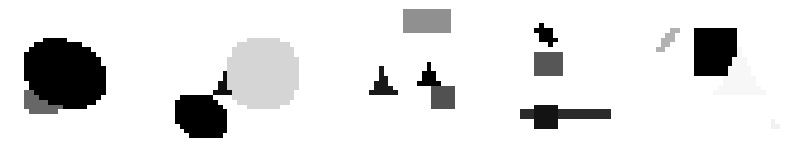

In [2]:
# Generar 1000 imágenes de símbolos abstractos y guardarlas en 'simbolos.npy'
import numpy as np
import matplotlib.pyplot as plt
from skimage.draw import random_shapes

simbolos = []

for _ in range(2000):
    img, _ = random_shapes(
        (28, 28),
        max_shapes=5,
        min_shapes=1,
        max_size=20,
        num_channels=1,  # Cambiado 'multichannel' a 'num_channels'
        intensity_range=((0, 255)),
        allow_overlap=True
    )
    img = img.astype('float32').squeeze() / 255.0  # Asegurar que la imagen es 2D
    simbolos.append(img)

simbolos = np.array(simbolos)

# Guardar las imágenes en 'simbolos.npy'
np.save('simbolos.npy', simbolos)

# Visualizar los primeros 5 símbolos
fig, axes = plt.subplots(1, 5, figsize=(10, 2))
for i in range(5):
    axes[i].imshow(simbolos[i], cmap='gray')
    axes[i].axis('off')
plt.show()

---

# Problema 1: Generación de Texto con Redes Neuronales Recurrentes

Utilizando el archivo `cuentos.txt`, tu tarea es construir un modelo de red neuronal recurrente que pueda generar texto (al menos en párrafo de 150 palabras) en el estilo de los cuentos proporcionados.

### Tareas:

1. **Preprocesamiento de Datos:**

   - Carga el texto desde `cuentos.txt` y realiza el preprocesamiento necesario.
   - Continúa con las instrucciones especificadas en el enunciado.

In [3]:
# Importar librerías necesarias
import numpy as np
import tensorflow as tf
import os
import time
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense
import requests



# Cargar el texto desde 'cuentos.txt'
with open('cuentos.txt', 'r', encoding='utf-8') as f:
    text = f.read()

# Hago lower para tener todas las letras en el formato que quiera, en caso de que
# haya algun problema

text = text.lower()

# Paso a tokenizar el texto
tokenizer = Tokenizer()
tokenizer.fit_on_texts([text])
total_words = len(tokenizer.word_index) + 1
print(f"Palabras: {total_words}")

# Para crear las secuencias de entrada
input_sequences = []
for line in text.split('.'):
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_sequence = token_list[:i+1]
        input_sequences.append(n_gram_sequence)

# Para rellenar las secuencias y crear etiquetas para los datos
max_seq_len = max([len(seq) for seq in input_sequences])
input_sequences = np.array(pad_sequences(input_sequences, maxlen=max_seq_len, padding='pre'))

X = input_sequences[:, :-1]
y = input_sequences[:, -1]

# Para convertir las etiquetas a categorias
y = tf.keras.utils.to_categorical(y, num_classes=total_words)
print(f"Categorias: {max_seq_len}")

Palabras: 181
Categorias: 22


In [4]:
# Para construir el modelo voy a usar una LSTM para no perder informacion en secuencias
# largas

model = Sequential()
model.add(Embedding(total_words, 128, input_length=max_seq_len-1))
model.add(LSTM(256, return_sequences= True))
model.add(LSTM(128))
model.add(Dense(total_words, activation='softmax'))

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [17]:
# Para entrenar el modelo
history = model.fit(X, y, epochs=200, verbose=1)
model.summary()

Epoch 1/200
120/120 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.8769 - loss: 0.3404
Epoch 2/200
120/120 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.8764 - loss: 0.3398
Epoch 3/200
120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8751 - loss: 0.3362
Epoch 4/200
120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8751 - loss: 0.3352
Epoch 5/200
120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8727 - loss: 0.3380
Epoch 6/200
120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8733 - loss: 0.3441
Epoch 7/200
120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8775 - loss: 0.3373
Epoch 8/200
120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8780 - loss: 0.3334
Epoch 9/200
120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8790 - loss: 0.3314
Epoch 10/200
120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8793 - loss: 0.3285
Epoch 11/200
120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8780 - loss: 0.3313
Epoch 12/200
120/120 ━━━━━━━━━━━━━━━━━━

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 21, 128)        │        23,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 21, 256)        │       394,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 128)            │       197,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 181)            │        23,349 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,913,633 (7.30 MB)

 Trainable params: 637,877 (2.43 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,275,756 (4.87 MB)

In [6]:
# Funcion para predecir la siguiente palabra:
def predict_next_word(model, tokenizer, text_seq):
    max_seq_len = model.input_shape[1] + 1
    token_list = tokenizer.texts_to_sequences([text_seq])[0]
    token_list = pad_sequences([token_list], maxlen=max_seq_len-1, padding='pre')
    predicted = model.predict(token_list, verbose=0)
    predicted_word_index = np.argmax(predicted, axis=1)[0]
    for word, index in tokenizer.word_index.items():
        if index == predicted_word_index:
            return word

In [18]:
# Para generar el parrafo solo repito la funcion una y otra vez

start = "Ulises me va a poner diez"
generated_text = start

for _ in range(150):
    next_word = predict_next_word(model, tokenizer, generated_text)
    generated_text += " " + next_word

print(f"Texto generado: \n{generated_text}")

Texto generado: 
Ulises me va a poner diez través de aventuras y desafíos juan aprendió que la verdadera riqueza está en el corazón corazón corazón corazón poderosas poderosas poderosas poderosas poderosas cambió poderosas poderosas poderosas poderosas poderosas poderosas aprendió cambió poderosas poderosas poderosas éxito bosque encantado alicia son las fuerzas más poderosas aprendió aprendió aprendió lámpara caperucita día caperucita través través través con botas que la verdadera riqueza corazón corazón corazón el corazón poderosas poderosas poderosas poderosas poderosas poderosas poderosas poderosas poderosas poderosas submarino poderosas poderosas poderosas poderosas submarino aprendió poderosas poderosas poderosas ciudad bosque encantado fuerzas son al éxito éxito más poderosas poderosas está en el corazón encantado submarino poderosas poderosas mágica aprendió aprendió fuerzas cambió cambió poderosas poderosas poderosas aprendió aprendió aprendió que través submarino submarino a

---

# Problema 2: Reconstrucción y Generación de Imágenes con Autoencoders y GANs

Utilizando el conjunto de imágenes `simbolos.npy`, que contiene 1000 imágenes de símbolos abstractos, explora el uso de Autoencoders y Generative Adversarial Networks (GANs) y generación de imágenes.

### Tareas:

1. **Autoencoder:**

   - Carga las imágenes desde `simbolos.npy` y normalízalas al rango [0, 1].
   - Continúa con las instrucciones especificadas en el enunciado.

In [23]:
# Importar librerías necesarias
import numpy as np
import tensorflow as tf
import os
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split

simbolos = np.load('simbolos.npy')
x_train, x_test = train_test_split(simbolos, test_size=0.2, random_state=42)

x_train = x_train.astype("float32")
x_test = x_test.astype("float32")

# Añadir la dimensión del canal
x_train = x_train[..., None]
x_test = x_test[..., None]

print("formas:", x_train.shape, x_test.shape)

latent_dim = 32

inputs = keras.Input(shape=(28, 28, 1), name="entrada")
e = layers.Conv2D(32, 3, activation="relu", padding="same")(inputs)
e = layers.MaxPooling2D()(e)
e = layers.Conv2D(64, 3, activation="relu", padding="same")(e)
e = layers.MaxPooling2D()(e)
e = layers.Flatten()(e)

mu = layers.Dense(latent_dim, name="mu")(e)
log_var = layers.Dense(latent_dim, name="log_var")(e)

def sample_z(args):
    mu_, log_var_ = args
    eps = tf.random.normal(shape=tf.shape(mu_))
    return mu_ + tf.exp(0.5 * log_var_) * eps

z = layers.Lambda(sample_z, name="amostrado")([mu, log_var])
encoder = keras.Model(inputs, [mu, log_var, z], name="encoder")
encoder.summary()

formas: (1600, 28, 28, 1) (400, 28, 28, 1)


Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ entrada             │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 28, 28,    │        320 │ entrada[0][0]     │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_8     │ (None, 14, 14,    │          0 │ conv2d_8[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 14, 14,    │     18,496 │ max_pooling2d_8[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_9     │ (None, 7, 7, 64)  │          0 │ conv2d_9[0][0]    │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_4 (Flatten) │ (None, 3136)      │          0 │ max_pooling2d_9[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mu (Dense)          │ (None, 32)        │    100,384 │ flatten_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ log_var (Dense)     │ (None, 32)        │    100,384 │ flatten_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ amostrado (Lambda)  │ (None, 32)        │          0 │ mu[0][0],         │
│                     │                   │            │ log_var[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 219,584 (857.75 KB)

 Trainable params: 219,584 (857.75 KB)

 Non-trainable params: 0 (0.00 B)

In [24]:
z_in = keras.Input(shape=(latent_dim,), name="z_in")
x = layers.Dense(7*7*64, activation="relu", name="dec_dense")(z_in)
x = layers.Reshape((7, 7, 64), name="dec_reshape")(x)
x = layers.Conv2DTranspose(64, 3, strides=2, activation="relu", padding="same", name="dec_deconv1")(x)
x = layers.Conv2DTranspose(32, 3, strides=2, activation="relu", padding="same", name="dec_deconv2")(x)
x_out = layers.Conv2D(1, 3, activation="sigmoid", padding="same", name="dec_out")(x)
decoder = keras.Model(z_in, x_out, name="decoder")

decoder.summary()

Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ z_in (InputLayer)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_dense (Dense)               │ (None, 3136)           │       103,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_reshape (Reshape)           │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_deconv1 (Conv2DTranspose)   │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_deconv2 (Conv2DTranspose)   │ (None, 28, 28, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_out (Conv2D)                │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 159,169 (621.75 KB)

 Trainable params: 159,169 (621.75 KB)

 Non-trainable params: 0 (0.00 B)

In [25]:
x_in = keras.Input(shape=(28, 28, 1), name="x_in")
mu_, log_var_, z_ = encoder(x_in)
x_recon = decoder(z_)
vae = keras.Model(x_in, x_recon, name="vae_simple")

mse_loss_fn = keras.losses.MeanSquaredError()
optimizer = keras.optimizers.Adam(1e-3)

@tf.function
def vae_loss(x_true, x_pred, mu_, log_var_):
    recon = mse_loss_fn(x_true, x_pred)
    kl = -0.5 * tf.reduce_mean(1 + log_var_ - tf.square(mu_) - tf.exp(log_var_))
    return recon + beta * kl, recon, kl

epochs = 20
batch_size = 256

train_ds = tf.data.Dataset.from_tensor_slices((x_train,)).batch(batch_size)
val_ds = tf.data.Dataset.from_tensor_slices((x_test,)).batch(batch_size)

train_hist, val_hist = [], []
for epoch in range(1, epochs + 1):
    epoch_losses = []
    for batch in train_ds:
        x_true_batch = batch[0]
        with tf.GradientTape() as tape:
            mu_val, log_var_val, z_val = encoder(x_true_batch, training=True)

            x_pred = decoder(z_val, training=True)

            total_loss, recon_loss, kl_loss = vae_loss(x_true_batch, x_pred, mu_val, log_var_val)

        grads = tape.gradient(total_loss, vae.trainable_variables)
        optimizer.apply_gradients(zip(grads, vae.trainable_variables))
        epoch_losses.append(float(total_loss))
    train_hist.append(np.mean(epoch_losses))

    val_losses = []
    for batch in val_ds:
        x_true_batch = batch[0]

        mu_val, log_var_val, z_val = encoder(x_true_batch, training=False)
        x_pred = decoder(z_val, training=False)

        total_loss, _, _ = vae_loss(x_true_batch, x_pred, mu_val, log_var_val)
        val_losses.append(float(total_loss))
    val_hist.append(np.mean(val_losses))

    print(f"época {epoch}/{epochs} - pérdida: {train_hist[-1]:.4f} - val: {val_hist[-1]:.4f}")

época 1/20 - pérdida: 0.2205 - val: 0.2050
época 2/20 - pérdida: 0.1504 - val: 0.0567
época 3/20 - pérdida: 0.0590 - val: 0.0558
época 4/20 - pérdida: 0.0532 - val: 0.0485
época 5/20 - pérdida: 0.0486 - val: 0.0463
época 6/20 - pérdida: 0.0471 - val: 0.0457
época 7/20 - pérdida: 0.0468 - val: 0.0455
época 8/20 - pérdida: 0.0464 - val: 0.0446
época 9/20 - pérdida: 0.0447 - val: 0.0416
época 10/20 - pérdida: 0.0412 - val: 0.0387
época 11/20 - pérdida: 0.0378 - val: 0.0363
época 12/20 - pérdida: 0.0366 - val: 0.0359
época 13/20 - pérdida: 0.0356 - val: 0.0353
época 14/20 - pérdida: 0.0350 - val: 0.0343
época 15/20 - pérdida: 0.0336 - val: 0.0325
época 16/20 - pérdida: 0.0317 - val: 0.0306
época 17/20 - pérdida: 0.0296 - val: 0.0291
época 18/20 - pérdida: 0.0284 - val: 0.0280
época 19/20 - pérdida: 0.0274 - val: 0.0271
época 20/20 - pérdida: 0.0265 - val: 0.0263


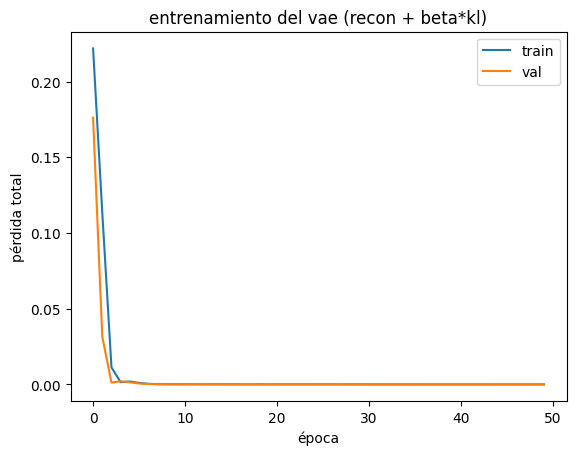

In [11]:
plt.figure()
plt.plot(train_hist, label="train")
plt.plot(val_hist, label="val")
plt.xlabel("época")
plt.ylabel("pérdida total")
plt.legend()
plt.title("entrenamiento del vae (recon + beta*kl)")
plt.show()

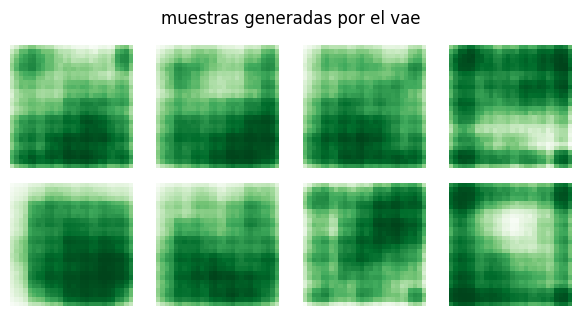

In [26]:
n = 8
z_samples = np.random.normal(size=(n, latent_dim)).astype("float32")
gen = decoder.predict(z_samples, verbose=0)

plt.figure(figsize=(6, 6))
for i in range(n):
    plt.subplot(4, 4, i + 1)
    plt.imshow(gen[i].squeeze(), cmap="Greens")
    plt.axis("off")
plt.suptitle("muestras generadas por el vae")
plt.tight_layout()
plt.show()

---

¡Éxito en tu examen! 🙂